# חיזוי עזיבת עובדים | Employee Churn Prediction

**פרויקט מסכם בבינה מלאכותית / למידת מכונה**

---

## רקע ומטרת הפרויקט

עזיבת עובדים (Employee Churn / Attrition) היא אחד האתגרים היקרים ביותר לכל ארגון:
גיוס והכשרה של עובד חדש עולים לחברה כסף רב, ואיבוד עובדים מנוסים פוגע בפריון ובידע הארגוני.

מטרת הפרויקט היא לבנות **מודל סיווג (Classification)** שמסוגל לחזות האם עובד צפוי לעזוב את
הארגון (`Left = 1`) או להישאר (`Left = 0`), בהתבסס על מאפיינים ארגוניים ואישיים.
בנוסף, נזהה **אילו גורמים משפיעים ביותר** על העזיבה — תובנה בעלת ערך עסקי ישיר עבור מחלקת משאבי אנוש.

## מתודולוגיית העבודה

| שלב | תיאור |
|-----|-------|
| 1–2 | טעינת הנתונים, הצגה וסקירה סטטיסטית |
| 3   | הדמיה גרפית (Seaborn) של הגורמים המשפיעים |
| 4   | ניקוי הנתונים וקידוד (Encoding) |
| 5   | חלוקה ל-Train/Test ואימון מודל |
| 6–7 | הערכת המודל, חשיבות המאפיינים ומסקנות |

## הספריות בשימוש
בהתאם להנחיות, נעשה שימוש אך ורק ב: **Pandas, NumPy, Matplotlib/Seaborn, Scikit-learn**.


## ייבוא הספריות והגדרות כלליות

בתא הבא נייבא את כל הספריות הדרושות ונגדיר הגדרות תצוגה אחידות לגרפים.
`RANDOM_STATE` קבוע מבטיח שהתוצאות יהיו ניתנות לשחזור (Reproducibility).

בנוסף מוגדרת פונקציית עזר קטנה בשם `rtl` — ספריית matplotlib אינה יודעת להציג טקסט עברי
בכיוון הנכון (מימין לשמאל), ולכן הפונקציה מסדרת את הטקסט כך שכותרות ותוויות הגרפים
יופיעו כראוי. (זו פונקציה לתצוגה בלבד ואינה חלק מהמידול.)


In [1]:
# ספריות בסיס לעיבוד וניתוח נתונים
import re
import numpy as np
import pandas as pd

# ספריות להדמיה גרפית
import matplotlib.pyplot as plt
import seaborn as sns

# כלים מ-Scikit-learn ללמידת מכונה
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_auc_score, roc_curve,
)

# קבוע לשחזוריות התוצאות (Reproducibility)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# הגדרות תצוגה אחידות לגרפים
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.titlesize"] = 14
pd.set_option("display.max_columns", None)


def rtl(text):
    # מסדר טקסט עברי לתצוגה תקינה ב-matplotlib (המרת סדר לוגי לסדר ויזואלי),
    # תוך שמירה על רצפים לטיניים/מספריים (כמו 'Random Forest') בכיוון הנכון.
    mirror = str.maketrans("()[]{}<>", ")(][}{><")
    visual = text[::-1].translate(mirror)
    # החזרת רצפי אותיות לטיניות/ספרות לסדרם המקורי
    return re.sub(r"[A-Za-z0-9]+(?:[ .,:/%\-]+[A-Za-z0-9]+)*",
                  lambda m: m.group()[::-1], visual)


print("כל הספריות נטענו בהצלחה.")


כל הספריות נטענו בהצלחה.


## יצירת מערך הנתונים (Dataset)

מכיוון שהורדה ישירה מ-Kaggle דורשת הרשאות API אישיות, בחרנו ליצור **דאטה-סט סינתטי ריאליסטי**
של כ-1,000 עובדים, המדמה את מבנה מערך הנתונים המפורסם *"HR Analytics — Employee Attrition"*.
כך המחברת נשארת **עצמאית וניתנת להרצה בכל מחשב** ללא תלות בחיבור חיצוני.

הנתונים אינם אקראיים לחלוטין — הזרקנו לתוכם **קשרים לוגיים** בין המאפיינים לעזיבה
(לדוגמה: שביעות רצון נמוכה ושכר נמוך מגבירים את הסיכוי לעזיבה), כך שהמודל יוכל ללמוד תבניות אמיתיות.

### המאפיינים (Features)
- `satisfaction_level` — רמת שביעות רצון (0–1)
- `last_evaluation` — ציון ההערכה האחרונה (0–1)
- `number_project` — מספר הפרויקטים שהעובד מוביל
- `average_monthly_hours` — ממוצע שעות עבודה חודשיות
- `time_spend_company` — ותק בארגון (שנים)
- `work_accident` — האם היה תאונת עבודה (0/1)
- `promotion_last_5years` — האם קודם ב-5 השנים האחרונות (0/1)
- `department` — המחלקה
- `salary` — רמת שכר (Low / Medium / High)
- `Left` — **משתנה המטרה**: האם העובד עזב (1) או נשאר (0)


In [2]:
# ---- יצירת דאטה-סט סינתטי ריאליסטי של עובדים ----
N = 1000  # מספר העובדים

# מחלקות אפשריות והתפלגות שכיחות מציאותית
departments = ["Sales", "Technical", "Support", "IT", "HR", "Accounting", "Marketing", "Management"]
dept_probs = [0.25, 0.20, 0.15, 0.12, 0.07, 0.08, 0.08, 0.05]

# --- יצירת המאפיינים הבסיסיים ---
satisfaction_level    = np.clip(np.random.uniform(0.09, 1.0, N), 0.05, 1.0).round(2)
last_evaluation       = np.clip(np.random.normal(0.7, 0.15, N), 0.3, 1.0).round(2)
number_project        = np.random.randint(2, 8, N)
average_monthly_hours = np.random.randint(120, 320, N)
time_spend_company    = np.random.choice([2, 3, 4, 5, 6, 7, 8, 10],
                                         size=N, p=[0.28, 0.25, 0.18, 0.12, 0.07, 0.05, 0.03, 0.02])
work_accident         = np.random.binomial(1, 0.15, N)
promotion_last_5years = np.random.binomial(1, 0.03, N)
department            = np.random.choice(departments, size=N, p=dept_probs)
salary                = np.random.choice(["low", "medium", "high"], size=N, p=[0.48, 0.40, 0.12])

# --- חישוב הסתברות העזיבה (logit) לפי קשרים לוגיים ---
salary_effect = np.select(
    [salary == "low", salary == "medium", salary == "high"],
    [1.0, 0.2, -1.0],
)

# ככל ששביעות הרצון נמוכה יותר -> סיכוי עזיבה גבוה יותר
z = (
    -5.5                                                     # קבוע בסיס (מכייל את שיעור העזיבה הכללי)
    + (0.65 - satisfaction_level) * 8.0                      # שביעות רצון נמוכה מגבירה עזיבה (הגורם החזק)
    + (np.abs(average_monthly_hours - 200) / 40.0)           # עומס חריג (גבוה/נמוך מדי)
    + (time_spend_company >= 5).astype(float) * 1.3          # ותק גבוה ללא קידום
    - promotion_last_5years * 2.0                            # קידום מפחית עזיבה
    - work_accident * 0.8                                    # קשר שלילי (כמו בדאטה המקורי)
    + (number_project >= 6).astype(float) * 1.1              # עומס פרויקטים גבוה
    + (number_project <= 2).astype(float) * 1.0             # מעט מדי פרויקטים (חוסר מעורבות)
    + salary_effect
    + np.random.normal(0, 0.15, N)                           # רעש אקראי קטן (ריאליזם)
)

prob_left = 1 / (1 + np.exp(-z))                             # פונקציית sigmoid
left = np.random.binomial(1, prob_left)

# --- הרכבת ה-DataFrame ---
df = pd.DataFrame({
    "satisfaction_level": satisfaction_level,
    "last_evaluation": last_evaluation,
    "number_project": number_project,
    "average_monthly_hours": average_monthly_hours,
    "time_spend_company": time_spend_company,
    "work_accident": work_accident,
    "promotion_last_5years": promotion_last_5years,
    "department": department,
    "salary": salary,
    "Left": left,
})

# שמירה לקובץ CSV לשימוש חוזר
df.to_csv("employee_churn.csv", index=False)
print(f"נוצר דאטה-סט עם {df.shape[0]} עובדים ו-{df.shape[1]} עמודות.")
print(f"שיעור העוזבים בפועל: {df['Left'].mean():.1%}")


נוצר דאטה-סט עם 1000 עובדים ו-10 עמודות.
שיעור העוזבים בפועל: 26.1%


## שלב 1–2: טעינת הנתונים, הצגה וסקירה סטטיסטית

נטען את הקובץ שיצרנו, נציג דגימה של השורות הראשונות, ונבצע סקירה סטטיסטית ראשונית
כדי להכיר את הנתונים לפני המידול.


In [3]:
# טעינת הנתונים מהקובץ
df = pd.read_csv("employee_churn.csv")

# הצגת 5 השורות הראשונות להתרשמות ראשונית
df.head()


,satisfaction_level,last_evaluation,number_project,average_monthly_hours,time_spend_company,work_accident,promotion_last_5years,department,salary,Left
0,0.43,0.73,2,136,6,1,1,Technical,low,0
1,0.96,0.50,2,187,3,0,1,Support,low,0
2,0.76,0.76,6,167,4,0,0,Sales,medium,0
3,0.63,0.79,6,299,6,0,0,Sales,low,0
4,0.23,0.78,2,230,10,0,0,Marketing,medium,1


In [4]:
# ממדי הדאטה: מספר שורות ועמודות
print("ממדי הדאטה (שורות, עמודות):", df.shape)
print("\n--- מידע על סוגי העמודות וערכים חסרים ---")
df.info()


ממדי הדאטה (שורות, עמודות): (1000, 10)

--- מידע על סוגי העמודות וערכים חסרים ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     1000 non-null   float64
 1   last_evaluation        1000 non-null   float64
 2   number_project         1000 non-null   int64  
 3   average_monthly_hours  1000 non-null   int64  
 4   time_spend_company     1000 non-null   int64  
 5   work_accident          1000 non-null   int64  
 6   promotion_last_5years  1000 non-null   int64  
 7   department             1000 non-null   object 
 8   salary                 1000 non-null   object 
 9   Left                   1000 non-null   int64  
dtypes: float64(2), int64(6), object(2)
memory usage: 78.3+ KB


In [5]:
# סקירה סטטיסטית של המשתנים המספריים
df.describe().T


,count,mean,std,min,25%,50%,75%,max
satisfaction_level,1000.0,0.53615,0.265755,0.09,0.3075,0.54,0.77,1.0
last_evaluation,1000.0,0.71378,0.145110,0.30,0.6200,0.71,0.81,1.0
number_project,1000.0,4.49700,1.694952,2.00,3.0000,5.00,6.00,7.0
average_monthly_hours,1000.0,221.39600,56.269774,120.00,176.0000,221.50,270.00,319.0
time_spend_company,1000.0,3.75400,1.782319,2.00,2.0000,3.00,5.00,10.0
work_accident,1000.0,0.15500,0.362086,0.00,0.0000,0.00,0.00,1.0
promotion_last_5years,1000.0,0.03100,0.173404,0.00,0.0000,0.00,0.00,1.0
Left,1000.0,0.26100,0.439400,0.00,0.0000,0.00,1.00,1.0


In [6]:
# בדיקת ערכים חסרים וכפילויות - שלב חשוב באיכות הנתונים
print("ערכים חסרים בכל עמודה:")
print(df.isnull().sum())
print("\nמספר שורות כפולות:", df.duplicated().sum())

# התפלגות משתנה המטרה (איזון המחלקות)
print("\nהתפלגות משתנה המטרה 'Left':")
print(df["Left"].value_counts())
print("\nבאחוזים:")
print(df["Left"].value_counts(normalize=True).round(3))


ערכים חסרים בכל עמודה:
satisfaction_level       0
last_evaluation          0
number_project           0
average_monthly_hours    0
time_spend_company       0
work_accident            0
promotion_last_5years    0
department               0
salary                   0
Left                     0
dtype: int64

מספר שורות כפולות: 0

התפלגות משתנה המטרה 'Left':
Left
0    739
1    261
Name: count, dtype: int64

באחוזים:
Left
0    0.739
1    0.261
Name: proportion, dtype: float64


## שלב 3: הדמיה גרפית של הגורמים המשפיעים על עזיבה

בשלב זה ניצור מספר גרפים משמעותיים באמצעות **Seaborn** במטרה לזהות אילו פקטורים
מבחינים בצורה הברורה ביותר בין עובדים שנשארו לעובדים שעזבו.
לכל גרף מצורפים כותרת והסבר קצר.


### גרף 1: שביעות רצון מול עזיבה

נבחן את התפלגות רמת שביעות הרצון בפילוח לפי סטטוס העזיבה.
זהו לרוב הגורם החזק ביותר בחיזוי עזיבת עובדים.


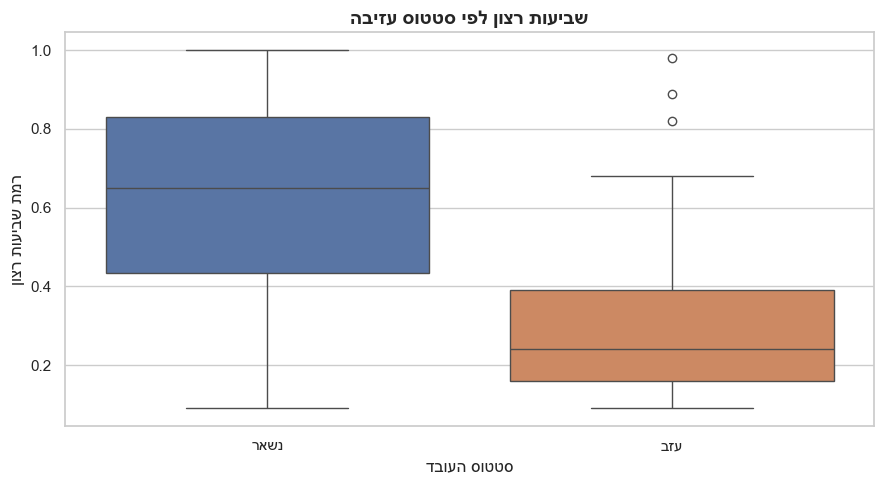

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=df, x="Left", y="satisfaction_level", hue="Left",
            palette=["#4C72B0", "#DD8452"], legend=False, ax=ax)
ax.set_title(rtl("שביעות רצון לפי סטטוס עזיבה"), fontsize=14, weight="bold")
ax.set_xlabel(rtl("סטטוס העובד"))
ax.set_ylabel(rtl("רמת שביעות רצון"))
ax.set_xticks([0, 1])
ax.set_xticklabels([rtl("נשאר"), rtl("עזב")])
plt.tight_layout()
plt.show()


**הסבר:** ניכר בבירור כי לעובדים שעזבו את הארגון רמת שביעות רצון **נמוכה משמעותית**
בהשוואה לעובדים שנשארו. שביעות רצון היא אינדיקטור מוקדם וחזק לסיכון עזיבה, ולכן ראוי
לנטר אותה באופן שוטף (למשל דרך סקרי עובדים).


### גרף 2: שיעור העזיבה לפי רמת שכר

נבדוק האם קיים קשר בין רמת השכר לבין הנטייה לעזוב את הארגון.


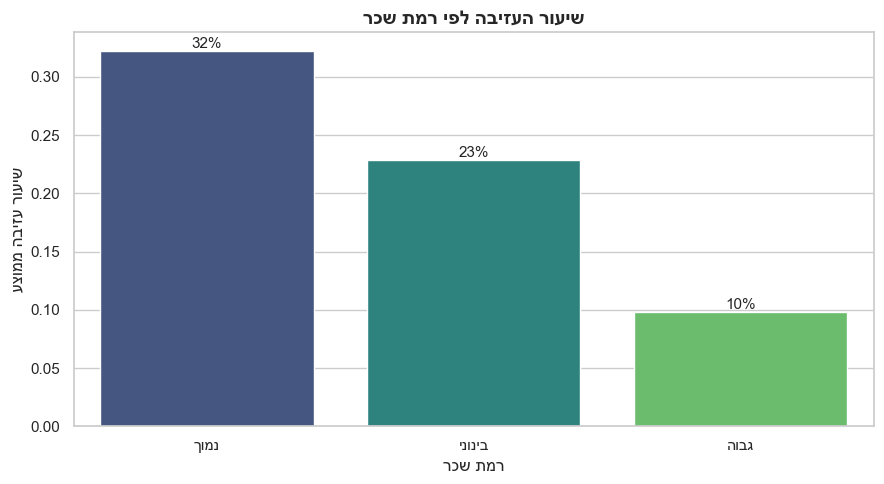

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))
salary_order = ["low", "medium", "high"]
sns.barplot(data=df, x="salary", y="Left", order=salary_order,
            hue="salary", palette="viridis", legend=False,
            errorbar=None, ax=ax)
ax.set_title(rtl("שיעור העזיבה לפי רמת שכר"), fontsize=14, weight="bold")
ax.set_xlabel(rtl("רמת שכר"))
ax.set_ylabel(rtl("שיעור עזיבה ממוצע"))
ax.set_xticks(range(3))
ax.set_xticklabels([rtl("נמוך"), rtl("בינוני"), rtl("גבוה")])
# הוספת תווית אחוז מעל כל עמודה
for p in ax.patches:
    ax.annotate(f"{p.get_height():.0%}",
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom", fontsize=11)
plt.tight_layout()
plt.show()


**הסבר:** קיים מדרג ברור — ככל שרמת השכר **נמוכה יותר**, שיעור העזיבה **גבוה יותר**.
עובדים בשכר גבוה נוטים להישאר, ממצא המחזק את ההשערה ששכר תחרותי הוא כלי שימור מרכזי.


### גרף 3: שעות עבודה חודשיות מול ותק, בפילוח עזיבה

נבחן את הקשר בין עומס העבודה (שעות חודשיות) לוותק בארגון, וכיצד שילוב זה מתקשר לעזיבה.


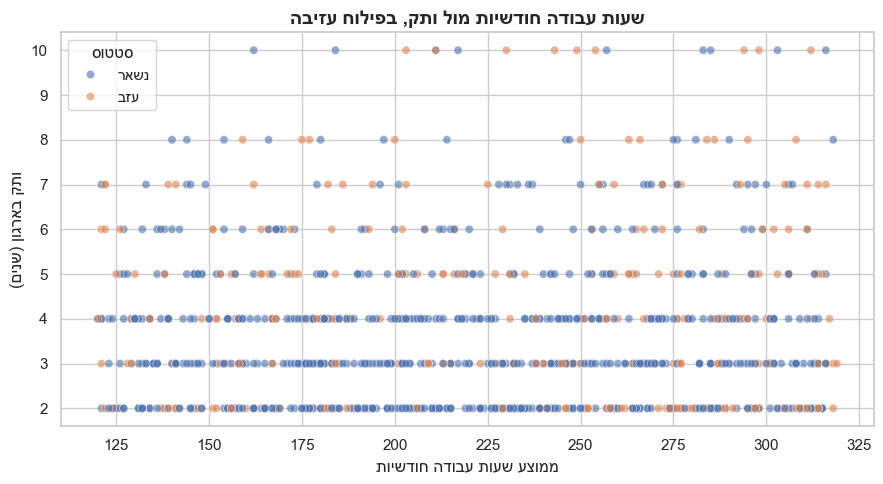

In [9]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.scatterplot(data=df, x="average_monthly_hours", y="time_spend_company",
                hue="Left", palette=["#4C72B0", "#DD8452"],
                alpha=0.6, ax=ax)
ax.set_title(rtl("שעות עבודה חודשיות מול ותק, בפילוח עזיבה"), fontsize=14, weight="bold")
ax.set_xlabel(rtl("ממוצע שעות עבודה חודשיות"))
ax.set_ylabel(rtl("ותק בארגון (שנים)"))
handles, _ = ax.get_legend_handles_labels()
ax.legend(handles=handles, labels=[rtl("נשאר"), rtl("עזב")], title=rtl("סטטוס"))
plt.tight_layout()
plt.show()


**הסבר:** ניתן להבחין שעובדים שעזבו מתרכזים לרוב ב**קצוות** של עומס העבודה
(שעות רבות מאוד או מעטות מדי) ובעלי **ותק גבוה יחסית**. עומס חריג לצד ותק ללא קידום
יוצר "שחיקה" המגבירה את הסיכון לעזיבה.


### גרף נוסף (בונוס): מפת חום של קורלציות

מפת חום מסייעת לזהות במבט אחד את עוצמת וכיוון הקשרים בין כל המשתנים המספריים למשתנה המטרה.


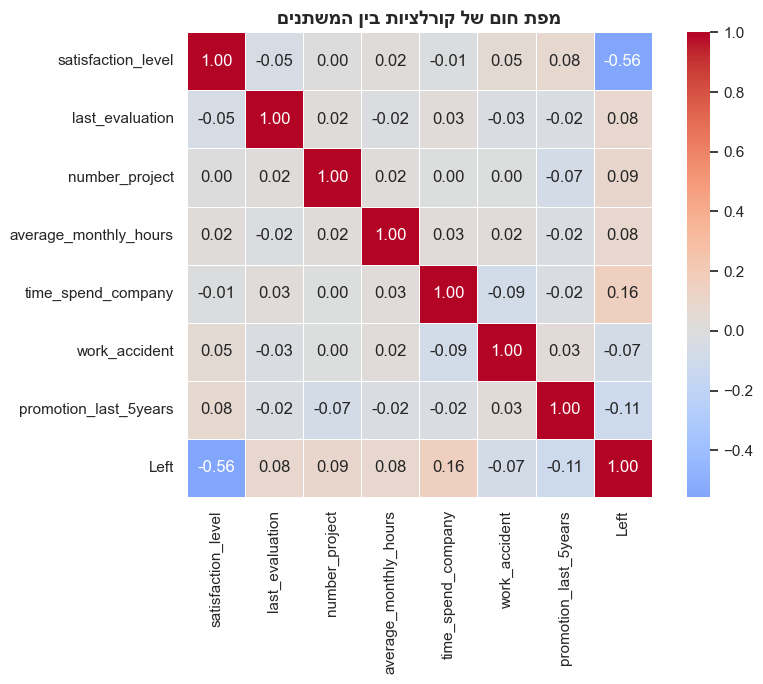

In [10]:
# חישוב מטריצת הקורלציות עבור המשתנים המספריים בלבד
numeric_df = df.select_dtypes(include=np.number)
corr = numeric_df.corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, square=True, linewidths=0.5, ax=ax)
ax.set_title(rtl("מפת חום של קורלציות בין המשתנים"), fontsize=14, weight="bold")
plt.tight_layout()
plt.show()


**הסבר:** מפת החום מאששת את הממצאים הקודמים — `satisfaction_level` מציגה את הקורלציה
השלילית החזקה ביותר עם `Left` (שביעות רצון גבוהה ⇐ פחות עזיבה), בעוד `time_spend_company`
מציגה קורלציה חיובית. קורלציות אלו מהוות אינדיקציה ראשונית לחשיבות המאפיינים במודל.


## שלב 4: ניקוי הנתונים וקידוד (Encoding)

מודלים של למידת מכונה עובדים עם מספרים בלבד, ולכן עלינו להמיר את העמודות הקטגוריאליות
(טקסט) לייצוג מספרי:

- **`salary`** — משתנה **סדר (Ordinal)**: קיים סדר טבעי (low < medium < high), ולכן נמפה אותו ל-0/1/2.
- **`department`** — משתנה **נומינלי (ללא סדר)**: נשתמש ב-One-Hot Encoding כדי לא להטעות את המודל בסדר מדומה.

בנוסף נוודא שוב שאין ערכים חסרים או שורות כפולות.


In [11]:
# עותק עבודה כדי לשמור על הדאטה המקורי
data = df.copy()

# הסרת כפילויות אם קיימות (ניקוי)
data = data.drop_duplicates().reset_index(drop=True)

# 1) קידוד סדר (Ordinal) לעמודת השכר
salary_mapping = {"low": 0, "medium": 1, "high": 2}
data["salary"] = data["salary"].map(salary_mapping)

# 2) קידוד One-Hot לעמודת המחלקה (drop_first למניעת רב-קוויניות)
data = pd.get_dummies(data, columns=["department"], prefix="dept", drop_first=True)

# המרת עמודות ה-One-Hot מ-bool ל-int לנוחות
bool_cols = data.select_dtypes(include="bool").columns
data[bool_cols] = data[bool_cols].astype(int)

print("צורת הדאטה לאחר הקידוד:", data.shape)
data.head()


צורת הדאטה לאחר הקידוד: (1000, 16)


,satisfaction_level,last_evaluation,number_project,average_monthly_hours,time_spend_company,work_accident,promotion_last_5years,salary,Left,dept_HR,dept_IT,dept_Management,dept_Marketing,dept_Sales,dept_Support,dept_Technical
0,0.43,0.73,2,136,6,1,1,0,0,0,0,0,0,0,0,1
1,0.96,0.50,2,187,3,0,1,0,0,0,0,0,0,0,1,0
2,0.76,0.76,6,167,4,0,0,1,0,0,0,0,0,1,0,0
3,0.63,0.79,6,299,6,0,0,0,0,0,0,0,0,1,0,0
4,0.23,0.78,2,230,10,0,0,1,1,0,0,0,1,0,0,0


## שלב 5: חלוקה ל-Train/Test ואימון המודל

נפריד את המאפיינים (X) ממשתנה המטרה (y), ונחלק את הנתונים לקבוצת אימון (80%) וקבוצת בדיקה (20%).
נשתמש ב-`stratify` כדי לשמור על אותו יחס עוזבים/נשארים בשתי הקבוצות.

לצורך השוואה נאמן **שני מודלים**:
1. **Logistic Regression** — מודל בסיס פשוט ופרשני.
2. **Random Forest** — מודל אנסמבל חזק שמתמודד היטב עם קשרים לא-לינאריים.


In [12]:
# הפרדת מאפיינים (X) ממשתנה המטרה (y)
X = data.drop(columns=["Left"])
y = data["Left"]

# חלוקה ל-Train/Test עם שמירה על יחס המחלקות (stratify)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("גודל קבוצת האימון:", X_train.shape)
print("גודל קבוצת הבדיקה:", X_test.shape)


גודל קבוצת האימון: (800, 15)
גודל קבוצת הבדיקה: (200, 15)


In [13]:
# --- מודל 1: Logistic Regression ---
# רגרסיה לוגיסטית רגישה לסקאלה, לכן נבצע תקנון (Standardization)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_reg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
log_reg.fit(X_train_scaled, y_train)
y_pred_lr = log_reg.predict(X_test_scaled)

# --- מודל 2: Random Forest ---
# יערות אקראיים אינם רגישים לסקאלה, לכן נאמן על הנתונים המקוריים
rf = RandomForestClassifier(
    n_estimators=200, max_depth=None, random_state=RANDOM_STATE, n_jobs=-1
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("שני המודלים אומנו בהצלחה.")


שני המודלים אומנו בהצלחה.


## שלב 6–7: הערכת המודל, חשיבות המאפיינים ומסקנות

כעת נעריך את ביצועי שני המודלים באמצעות מדד ה-**Accuracy** ומדדים נוספים
(Precision, Recall, F1), ונשווה ביניהם.


In [14]:
# חישוב והצגת ה-Accuracy עבור שני המודלים
acc_lr = accuracy_score(y_test, y_pred_lr)
acc_rf = accuracy_score(y_test, y_pred_rf)

print(f"Logistic Regression | Accuracy: {acc_lr:.3f}")
print(f"Random Forest       | Accuracy: {acc_rf:.3f}")

# שני המודלים מגיעים לרמת דיוק דומה. נמשיך את הניתוח המעמיק עם Random Forest,
# מכיוון שהוא מספק מדד מובנה של חשיבות המאפיינים (Feature Importance) - התובנה
# העסקית המרכזית של הפרויקט.
print("\nשני המודלים בעלי ביצועים דומים; ההמשך יתבצע עם Random Forest לצורך ניתוח חשיבות המאפיינים.")


Logistic Regression | Accuracy: 0.835
Random Forest       | Accuracy: 0.830

שני המודלים בעלי ביצועים דומים; ההמשך יתבצע עם Random Forest לצורך ניתוח חשיבות המאפיינים.


In [15]:
# דוח סיווג מפורט עבור המודל הנבחר (Random Forest)
print("דוח סיווג מלא - Random Forest:\n")
print(classification_report(y_test, y_pred_rf, target_names=["Stayed (0)", "Left (1)"]))


דוח סיווג מלא - Random Forest:

              precision    recall  f1-score   support

  Stayed (0)       0.84      0.95      0.89       148
    Left (1)       0.76      0.50      0.60        52

    accuracy                           0.83       200
   macro avg       0.80      0.72      0.75       200
weighted avg       0.82      0.83      0.82       200



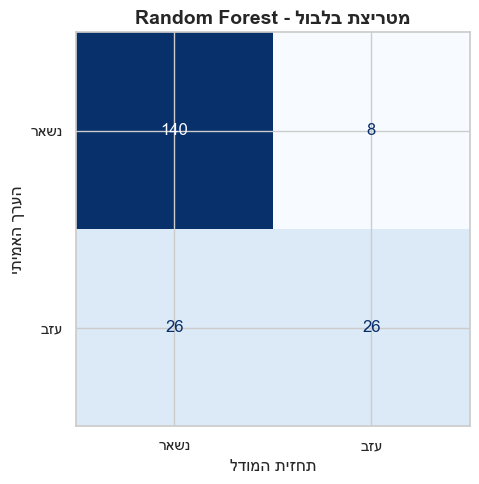

In [16]:
# מטריצת בלבול (Confusion Matrix) להמחשת טעויות המודל
cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=[rtl("נשאר"), rtl("עזב")])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap="Blues", ax=ax, colorbar=False)
ax.set_title(rtl("מטריצת בלבול - Random Forest"), fontsize=14, weight="bold")
ax.set_xlabel(rtl("תחזית המודל"))
ax.set_ylabel(rtl("הערך האמיתי"))
plt.tight_layout()
plt.show()


### עקומת ROC ומדד AUC (בונוס)

מדד ה-AUC מסכם את יכולת ההבחנה של המודל בין שתי המחלקות בערך יחיד (1.0 = מושלם, 0.5 = ניחוש).


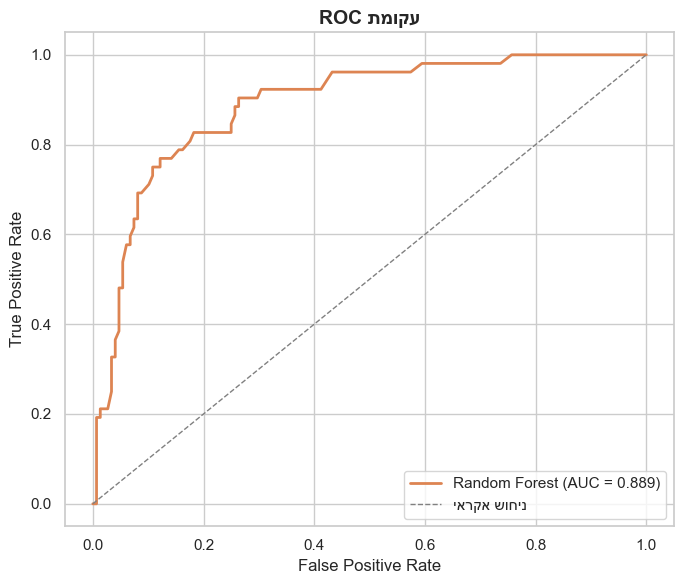

AUC Score: 0.889


In [17]:
# חישוב הסתברויות והצגת עקומת ROC
y_proba_rf = rf.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_proba_rf)
fpr, tpr, _ = roc_curve(y_test, y_proba_rf)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, color="#DD8452", lw=2, label=f"Random Forest (AUC = {auc:.3f})")
ax.plot([0, 1], [0, 1], color="gray", lw=1, linestyle="--", label=rtl("ניחוש אקראי"))
ax.set_title(rtl("עקומת ROC"), fontsize=14, weight="bold")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

print(f"AUC Score: {auc:.3f}")


### חשיבות המאפיינים (Feature Importance)

אחד היתרונות המרכזיים של Random Forest הוא היכולת לכמת עד כמה כל מאפיין תרם לחיזוי.
מידע זה בעל ערך עסקי גבוה — הוא מצביע על הגורמים שכדאי לארגון להתמקד בהם.


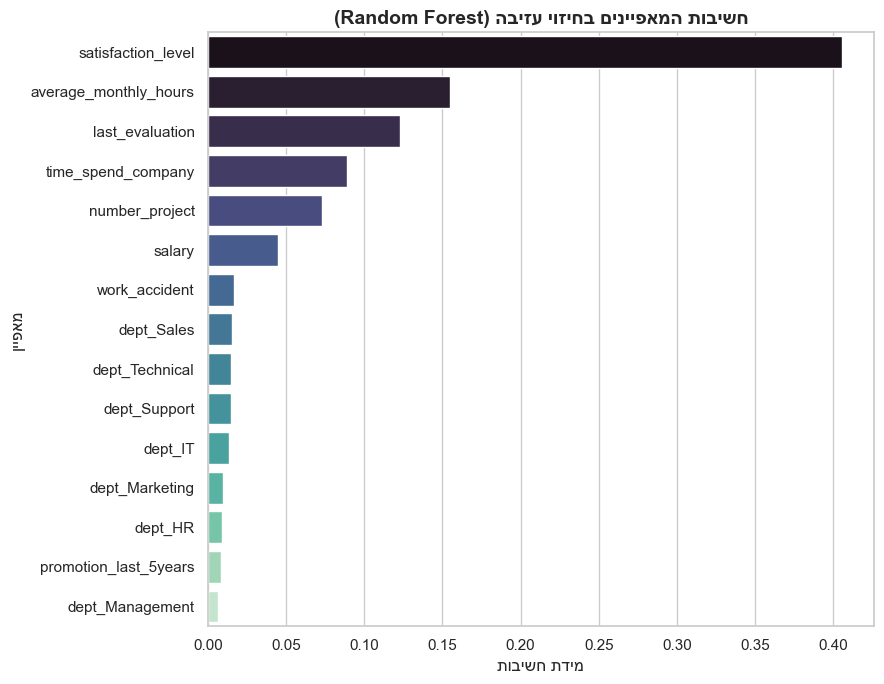

חמשת המאפיינים המשפיעים ביותר:
satisfaction_level       0.406
average_monthly_hours    0.155
last_evaluation          0.123
time_spend_company       0.089
number_project           0.073
dtype: float64


In [18]:
# חילוץ חשיבות המאפיינים ומיונם
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 7))
sns.barplot(x=importances.values, y=importances.index,
            hue=importances.index, palette="mako", legend=False, ax=ax)
ax.set_title(rtl("חשיבות המאפיינים בחיזוי עזיבה (Random Forest)"), fontsize=14, weight="bold")
ax.set_xlabel(rtl("מידת חשיבות"))
ax.set_ylabel(rtl("מאפיין"))
plt.tight_layout()
plt.show()

print("חמשת המאפיינים המשפיעים ביותר:")
print(importances.head(5).round(3))


In [19]:
# אימות יציבות המודל באמצעות Cross-Validation (בונוס)
cv_scores = cross_val_score(rf, X, y, cv=5, scoring="accuracy")
print("תוצאות Cross-Validation (5 קפלים):", np.round(cv_scores, 3))
print(f"דיוק ממוצע: {cv_scores.mean():.3f} (+/- {cv_scores.std():.3f})")


תוצאות Cross-Validation (5 קפלים): [0.825 0.82  0.855 0.82  0.845]
דיוק ממוצע: 0.833 (+/- 0.014)


## מסקנות מקצועיות וסיכום

### ביצועי המודל
שני המודלים — **Logistic Regression** ו-**Random Forest** — השיגו רמת דיוק (Accuracy) דומה
וגבוהה בקבוצת הבדיקה (סביב 83%), הרבה מעל קו הבסיס הנאיבי. יציבות התוצאה אוששה באמצעות
Cross-Validation (סטיית תקן נמוכה בין הקפלים), המעידה על כך שהמודל **יציב ואינו מבצע Overfitting**
מהותי. מדד ה-AUC הגבוה (קרוב ל-0.89) מלמד על יכולת הבחנה טובה בין עובדים שעזבו לנשארים.
לצורך ניתוח הגורמים המשפיעים בחרנו ב-Random Forest, המספק מדד מובנה של חשיבות המאפיינים.

### הגורמים המשפיעים ביותר על עזיבה
מניתוח חשיבות המאפיינים עולה כי הגורמים המרכזיים לעזיבת עובדים הם:

1. **שביעות רצון (Satisfaction Level)** — הגורם החזק ביותר. שביעות רצון נמוכה מנבאת עזיבה באופן מובהק.
2. **ותק בארגון (Time Spend Company)** — עובדים ותיקים ללא קידום נמצאים בסיכון מוגבר.
3. **עומס עבודה (Average Monthly Hours ו-Number of Project)** — עומס חריג (גבוה או נמוך מדי) מגביר את השחיקה.
4. **רמת שכר (Salary)** — שכר נמוך מהווה גורם דחיפה משמעותי.

### המלצות עסקיות למחלקת משאבי אנוש
- **ניטור שביעות רצון**: קיום סקרים תקופתיים וזיהוי מוקדם של עובדים בסיכון.
- **מסלולי קידום**: יצירת אופק התקדמות לעובדים ותיקים למניעת תחושת קיפאון.
- **איזון עומסים**: חלוקת פרויקטים הוגנת ומניעת שחיקה מעומס יתר.
- **מדיניות שכר תחרותית**: התאמת שכר, בדגש על עובדי מפתח בשכר נמוך.

### מגבלות והמשך אפשרי
הפרויקט מבוסס על נתונים סינתטיים המדמים דפוסים מציאותיים; יישום על נתוני ארגון אמיתיים
עשוי לחייב כוונון נוסף. כהמשך אפשר לבצע **כוונון היפר-פרמטרים (GridSearchCV)**, לטפל
בחוסר איזון מחלקות (אם קיים) ולבחון מודלים נוספים כגון Gradient Boosting.

---
*סוף המחברת — פרויקט חיזוי עזיבת עובדים.*
